### Instructions:
1) submit a simple script in either language that implements the main functions of the integrate and fire neuron. Write this by hand. You should manually type every character. It should be minimal. It should have values for the resting potential (I suggest 0), a threshold, a tau value, and a mechanism for indicating a "spike". You do not need to plot it, yet. You do need to save all the numbers for time and voltage and current so that a plot is possible. You ought to be able to start with your spring script (that is allowed even if that was written by AI), and edit it to use the new equation(s).

2) use part one to generate a single static plot/image that shows the voltage and current traces and some spikes. Try to time the cessation of your current pulse so that you can observe what happens to the voltage trace after the current is shut off. Why does it look that way? You can answer that in a comment in your code. It is permissible to seek out some AI advice here, but this is still something you might want to be able to do on your own.

In [6]:
def simulate_neuron(I=2, R=10, C=2, dt=0.1, total_time=200, V=-70):
    V_rest = -70
    threshold = -55
    reset = -70
    tau = R * C

    time = 0
    times = []
    voltages = []
    currents = []

    while time < total_time:

        #current turns off after 100 ms
        if time < 100:
            current = I
        else:
            current = 0
            
        dV =  (V_rest - V + R * current) / tau
        V = V + dV * dt
        
        if V >= threshold:
            times.append(time)
            voltages.append(threshold)
            currents.append(current)
            V = reset
        
        times.append(time)
        voltages.append(V)
        currents.append(current)
        time = time + dt

    return times, voltages, currents


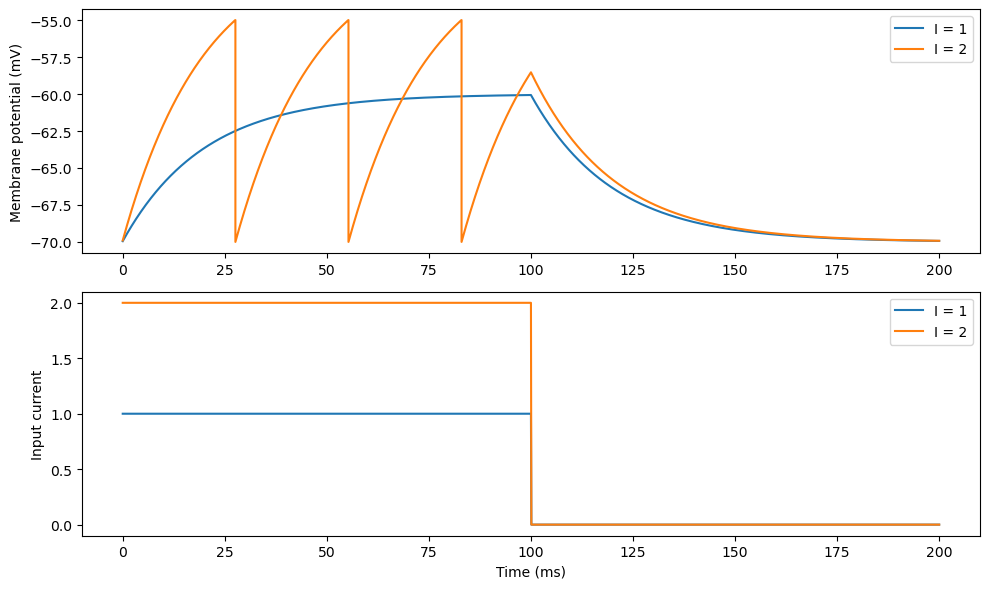

In [7]:
import matplotlib.pyplot as plt

times1, voltages1, currents1 = simulate_neuron(I=1)
times2, voltages2, currents2 = simulate_neuron(I=2)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(times1, voltages1, label="I = 1")
plt.plot(times2, voltages2, label="I = 2")
plt.ylabel("Membrane potential (mV)")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(times1, currents1, label="I = 1")
plt.plot(times2, currents2, label="I = 2")
plt.xlabel("Time (ms)")
plt.ylabel("Input current")
plt.legend()

plt.tight_layout()
plt.show()

I set the input current to stop at 100 ms so I could observe what happens to the membrane potential when the current is removed. The voltage gradually returns toward it's resting potential (−70 mV) instead of dropping immediately. It's because the membrane stores electrical charge, which takes time to go down through the leak channels. The voltage decreases faster at first because it is further from its resting potential but as it gets closer, the leak current becomes smaller.

I also created 2 plots, with different I values. With I = 1, the membrane potential increases but doesn't reach the threshold (−55 mV), so the neuron doesn't fire. With I = 2, the stronger current causes the membrane potential to reach the threshold repeatedly, producing spikes. When the current stops at 100 ms, both neurons gradually return toward their resting potential (−70 mV).

In [8]:
from ipywidgets import interact, FloatSlider

def interactive_neuron(I=2, R=10, C=2, V=-70):

    times, voltages, currents = simulate_neuron(
        I=I, R=R, C=C, V=V
    )

    plt.figure(figsize=(10, 6))

    plt.subplot(2, 1, 1)
    plt.plot(times, voltages)
    plt.axhline(-55, color="red", linestyle="--", label="Threshold")
    plt.ylabel("Membrane potential (mV)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(times, currents)
    plt.xlabel("Time (ms)")
    plt.ylabel("Input current")

    plt.tight_layout()
    plt.show()

interact(
    interactive_neuron,
    I=FloatSlider(value=2, min=0, max=5, step=0.1),
    R=FloatSlider(value=10, min=1, max=20, step=1),
    C=FloatSlider(value=2, min=0.5, max=5, step=0.5),
    V=FloatSlider(value=-70, min=-80, max=-50, step=1)
)

interactive(children=(FloatSlider(value=2.0, description='I', max=5.0), FloatSlider(value=10.0, description='R…

<function __main__.interactive_neuron(I=2, R=10, C=2, V=-70)>